In [30]:
import os
import math 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [31]:
path = r"D:\class\Fifth_sem\Data_mining\Data_Minining_Mini_Project\Bank_Marketing_Analysis\Prep_data\Formated_data\combined_additional.csv"
df = pd.read_csv(path)

## Data Understanding

In [32]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [33]:
df.shape

(41176, 21)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

In [35]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [36]:
temporal_features = ['month', 'day_of_week']

target_column = ['y']

numeric_features = [col for col in df.select_dtypes('number')
              if col!= temporal_features and col!= target_column]

categorical_features = [col for col in df.select_dtypes('object')
                    if col!= temporal_features and col!= target_column]


numeric_df = df[numeric_features]
categorical_df = df[categorical_features]
temporal_df = df[temporal_features]
target_df = df[target_column]

In [37]:
print(f"Numeric: {len(numeric_features)} | Categorical: {len(categorical_features)} | Temporal: {len(temporal_features)}")

Numeric: 10 | Categorical: 11 | Temporal: 2


In [38]:
# Calculate the percentage of "unknown" values per column in categorical
def check_unknowns(df):
    unknown_report = {}
    for col in df.columns:
        # Count string "unknown" or actual nulls
        count = (df[col] == 'unknown').sum() + df[col].isnull().sum()
        percentage = (count / len(df)) * 100
        unknown_report[col] = f"{percentage:.2f}%"
    return pd.Series(unknown_report)

print(check_unknowns(categorical_df))

job             0.80%
marital         0.19%
education       4.20%
default        20.88%
housing         2.40%
loan            2.40%
contact         0.00%
month           0.00%
day_of_week     0.00%
poutcome        0.00%
y               0.00%
dtype: object


In [39]:
integrity_issue = df[(df['previous'] == 0) & (df['pdays'] != 999)]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 0


In [40]:
integrity_issue = df[(df['duration'] == 0) & (df['y'] != 'no')]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 0


In [41]:
df['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [42]:
integrity_issue = df[(df['poutcome'] == 'success') & (df['previous'] == 0)]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 0


In [43]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [44]:
integrity_issue = df[(df['job'] == 'retired') & (df['age'] <= 63)]
print(f'outliers found in job w.r.t age: {len(integrity_issue)}')

outliers found in job w.r.t age: 1126


#### Data visualization

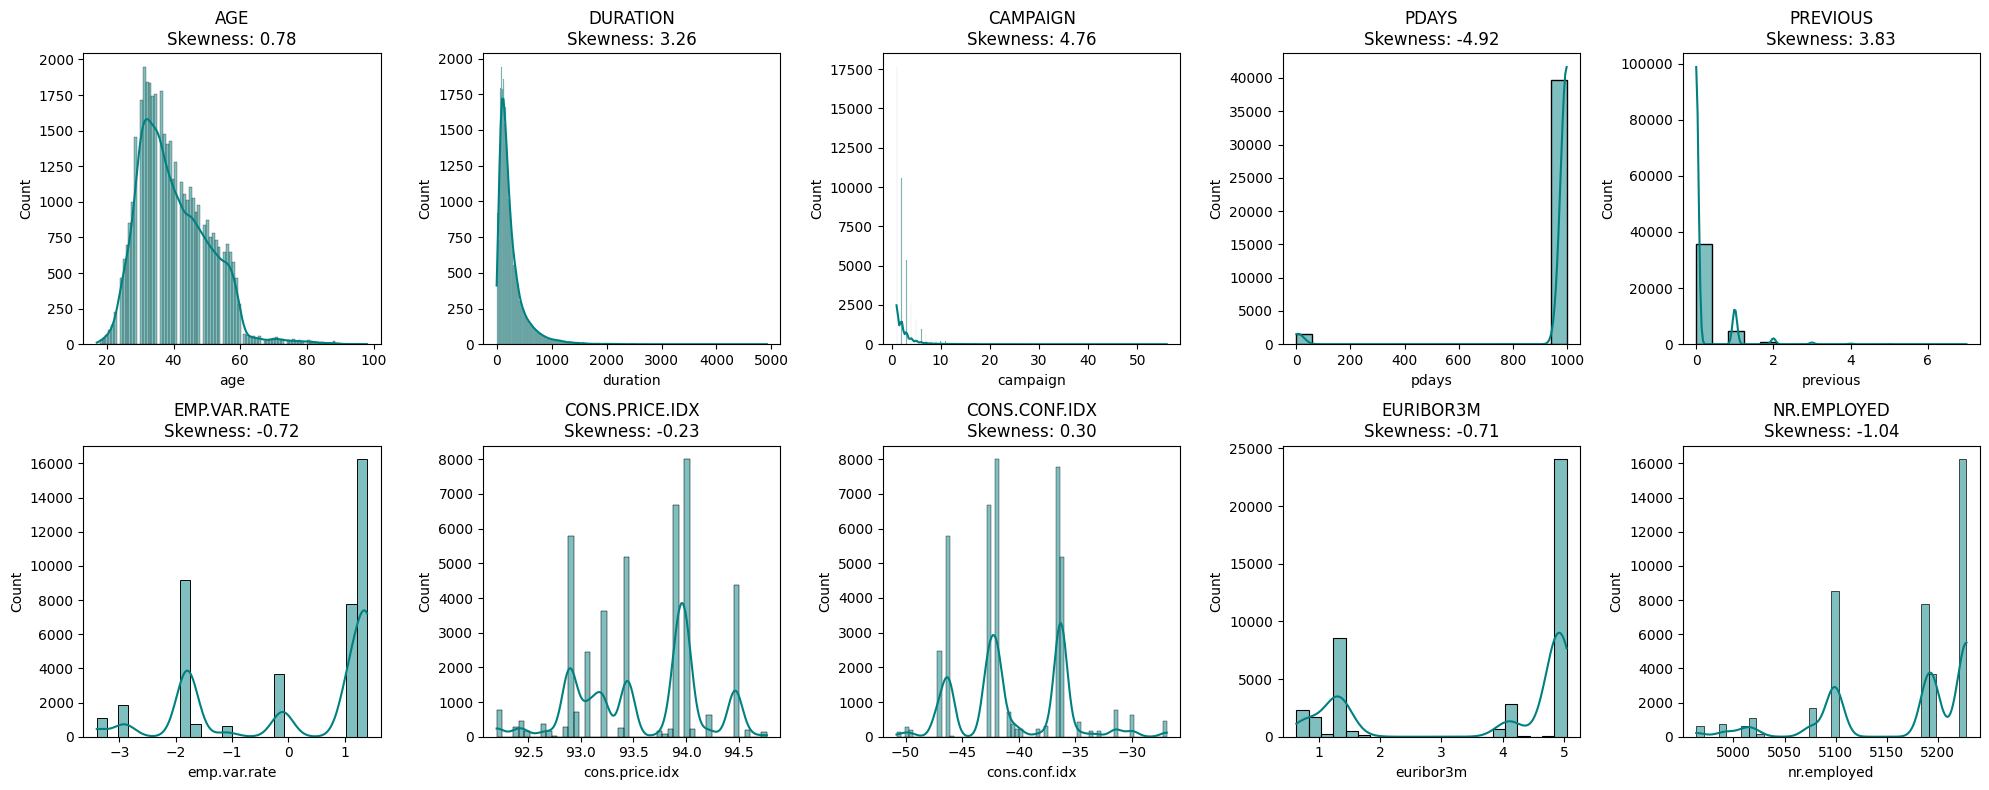

In [45]:
out_dir = 'Report\\EDA\\Grouped_distribution_plot'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
    
def univariate_analysis(df, numeric_cols):
    plt.figure(figsize=(20, 8))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 5, i)  # 2 rows, 5 columns for 10 features
        
        # Combine Histogram with a Kernel Density Estimate (KDE)
        sns.histplot(df[col], kde=True, color='teal')
        
        # Calculate skewness to report in the title
        sk_val = skew(df[col])
        plt.title(f'{col.upper()}\nSkewness: {sk_val:.2f}')
    
    plt.savefig(os.path.join(out_dir, "histplot.png"))
    plt.tight_layout()
    plt.show()

# Execution
univariate_analysis(df, numeric_features)

In [46]:
def group(df, target='y'):
    df_temp = df.copy()
    if df[target].dtype == 'object':
        df_temp[target] = df_temp[target].map({'yes': 1, 'no': 0})
        print(type(df_temp.groupby('job')[target].value_counts()))
        value_store = df_temp.groupby('job')[target].value_counts()[:2]
        mean_store = df_temp.groupby('job')[target].mean()[:1]
        print(value_store)
        print(mean_store)

group(df)

<class 'pandas.core.series.Series'>
job     y
admin.  0    9068
        1    1351
Name: count, dtype: int64
job
admin.    0.129667
Name: y, dtype: float64


C:\Users\nisch\AppData\Local\Temp\ipykernel_20840\1295081588.py:41: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



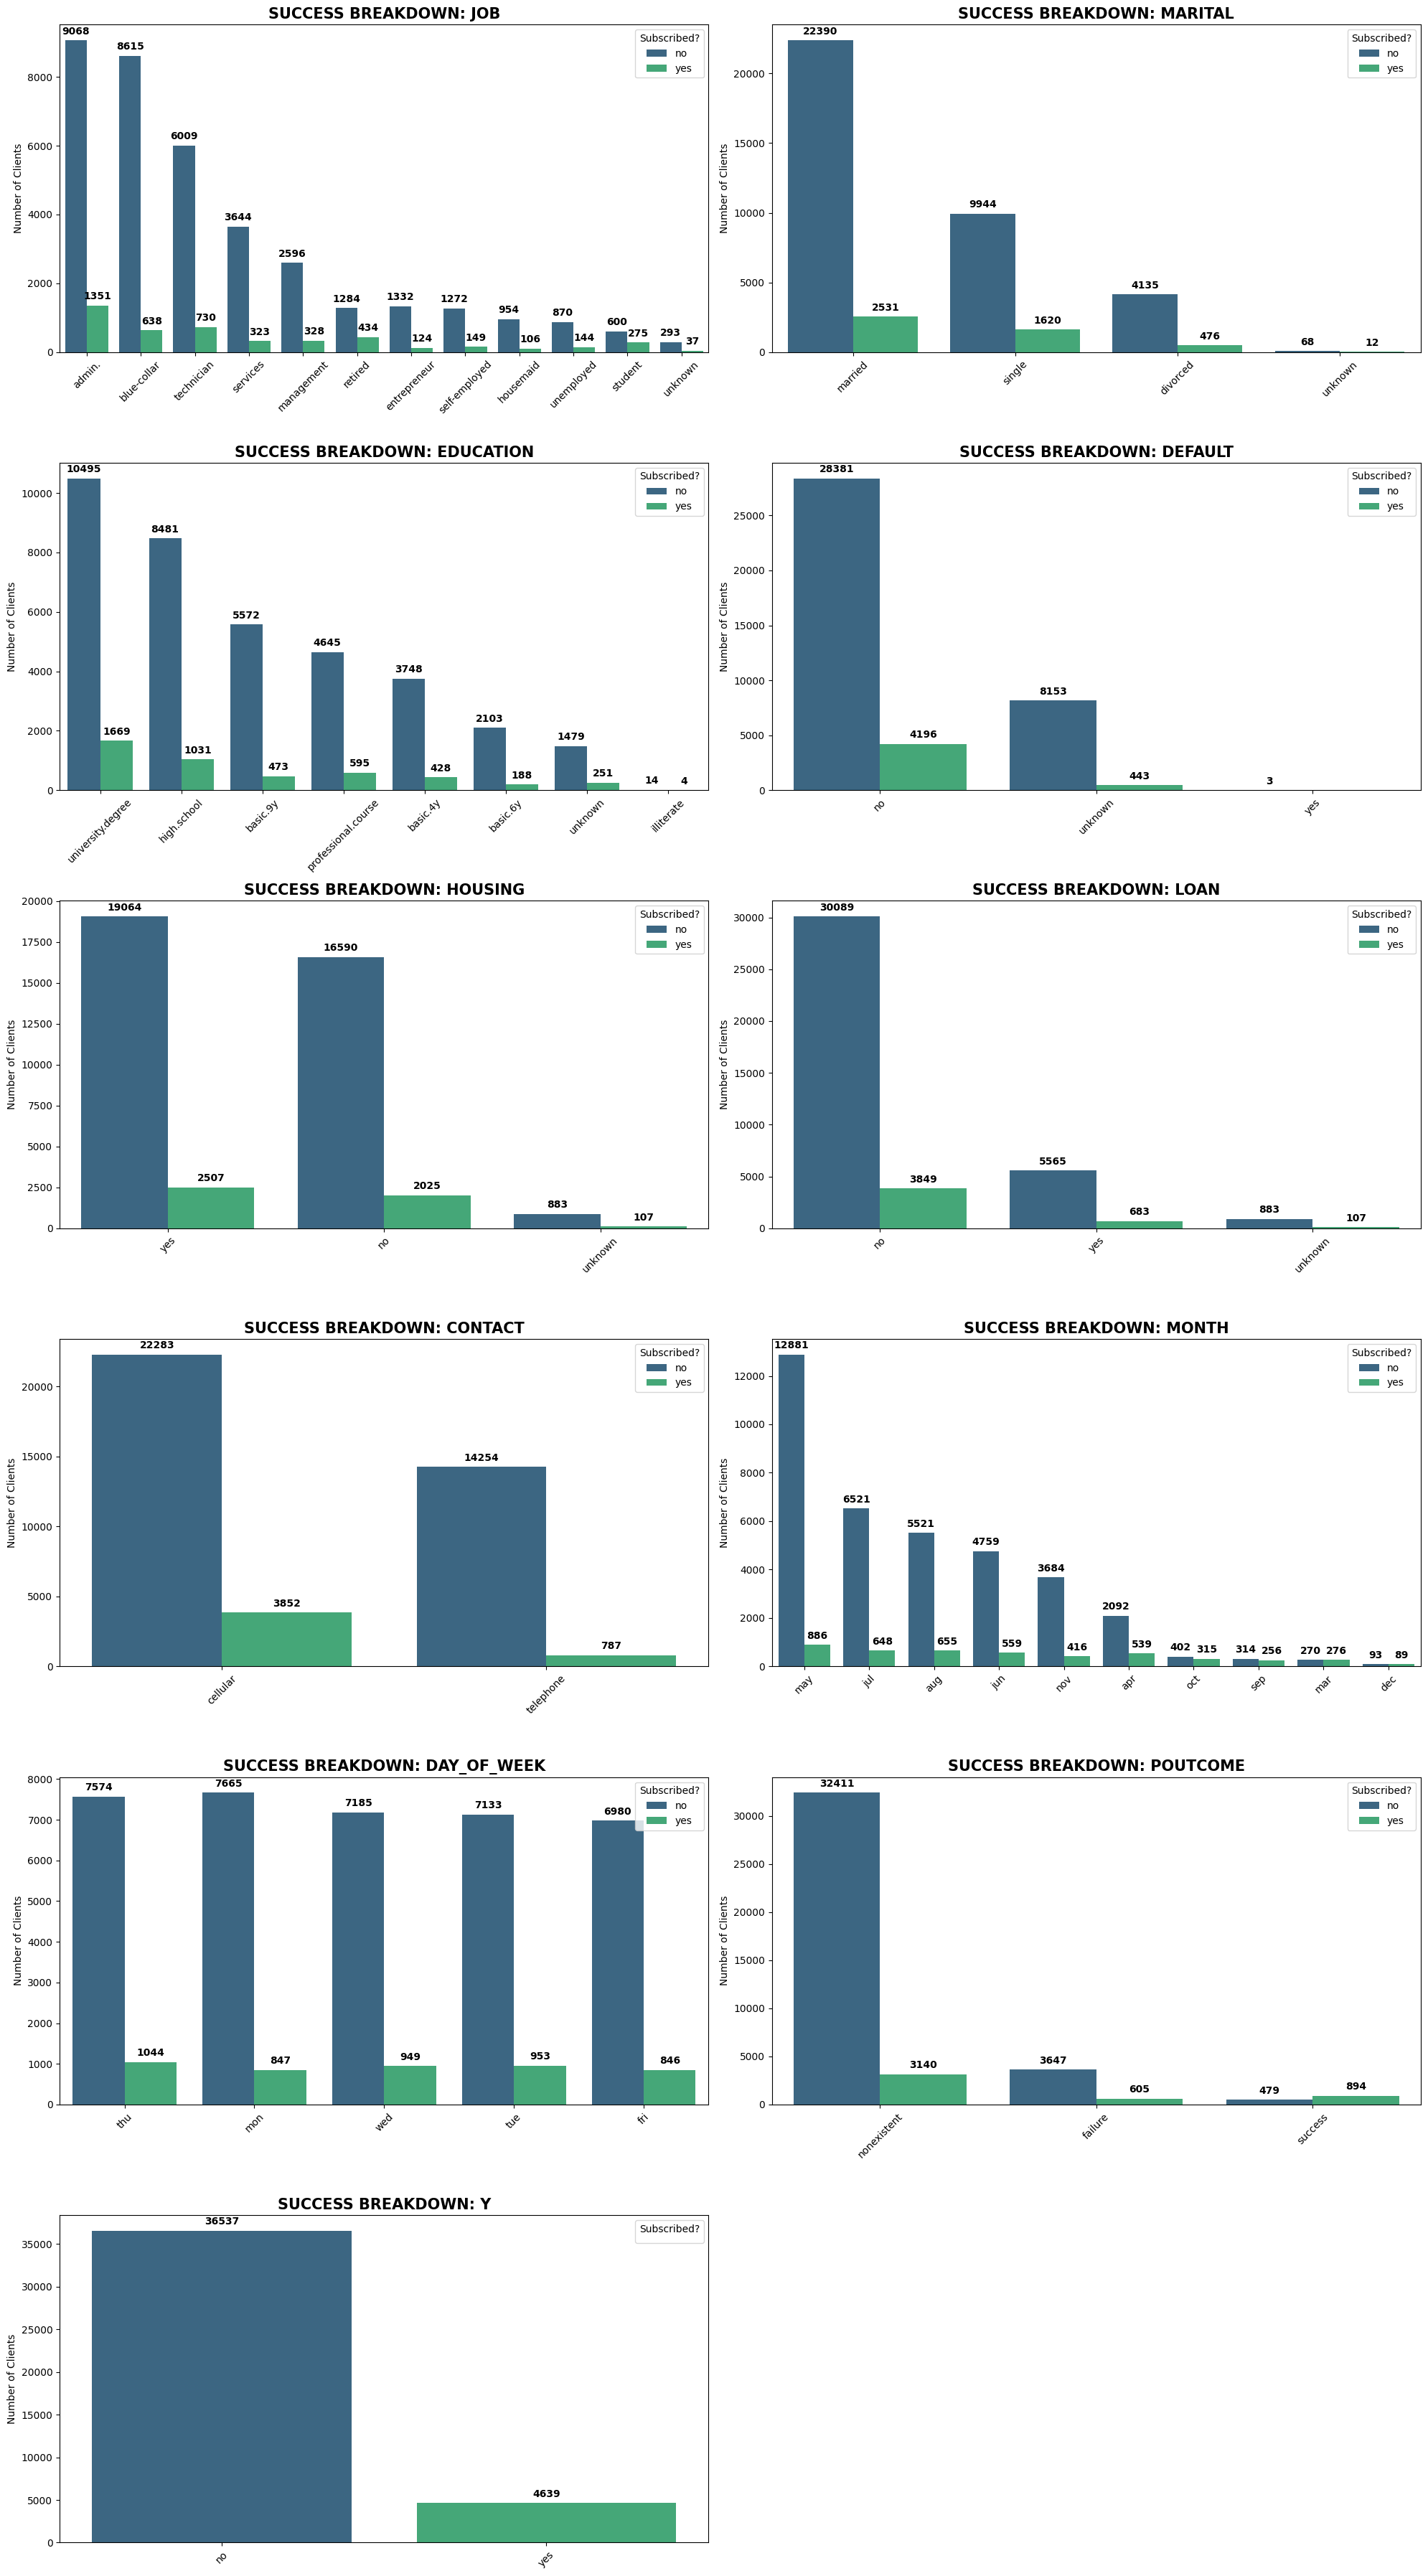

In [47]:
out_dir = 'Report\\EDA\\Grouped_countplot'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

def plot_success_distribution(df, cat_cols, target='y'):
    # 1. Setup Grid
    num_plots = len(cat_cols)
    n_cols = 2
    n_rows = math.ceil(num_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # 2. Create Countplot with Target as 'Hue'
        # This shows 'Yes' and 'No' side-by-side for every category
        sns.countplot(
            x=col, 
            data=df, 
            hue=target, 
            ax=axes[i],
            order=df[col].value_counts().index,
            palette='viridis'
        )

        # 3. SENIOR STEP: Add exact value labels on top of each bar
        for p in axes[i].patches:
            height = p.get_height()
            if height > 0: # Only label bars that have data
                axes[i].annotate(f'{int(height)}', 
                                 (p.get_x() + p.get_width() / 2., height), 
                                 ha='center', va='center', 
                                 xytext=(0, 9), 
                                 textcoords='offset points',
                                 fontsize=10, fontweight='bold')

        # 4. Formatting
        axes[i].set_title(f'SUCCESS BREAKDOWN: {col.upper()}', fontsize=15, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Number of Clients')
        axes[i].legend(title='Subscribed?', loc='upper right')
        axes[i].tick_params(axis='x', rotation=45)

    # Clean up empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'Grouped_Bar_Plot'))
    plt.show()

# Execution
plot_success_distribution(df, categorical_df.columns.to_list())

Master Signal Plot saved to: Report\EDA\Convergence_Bar_Plot\master_bivariate_analysis.png


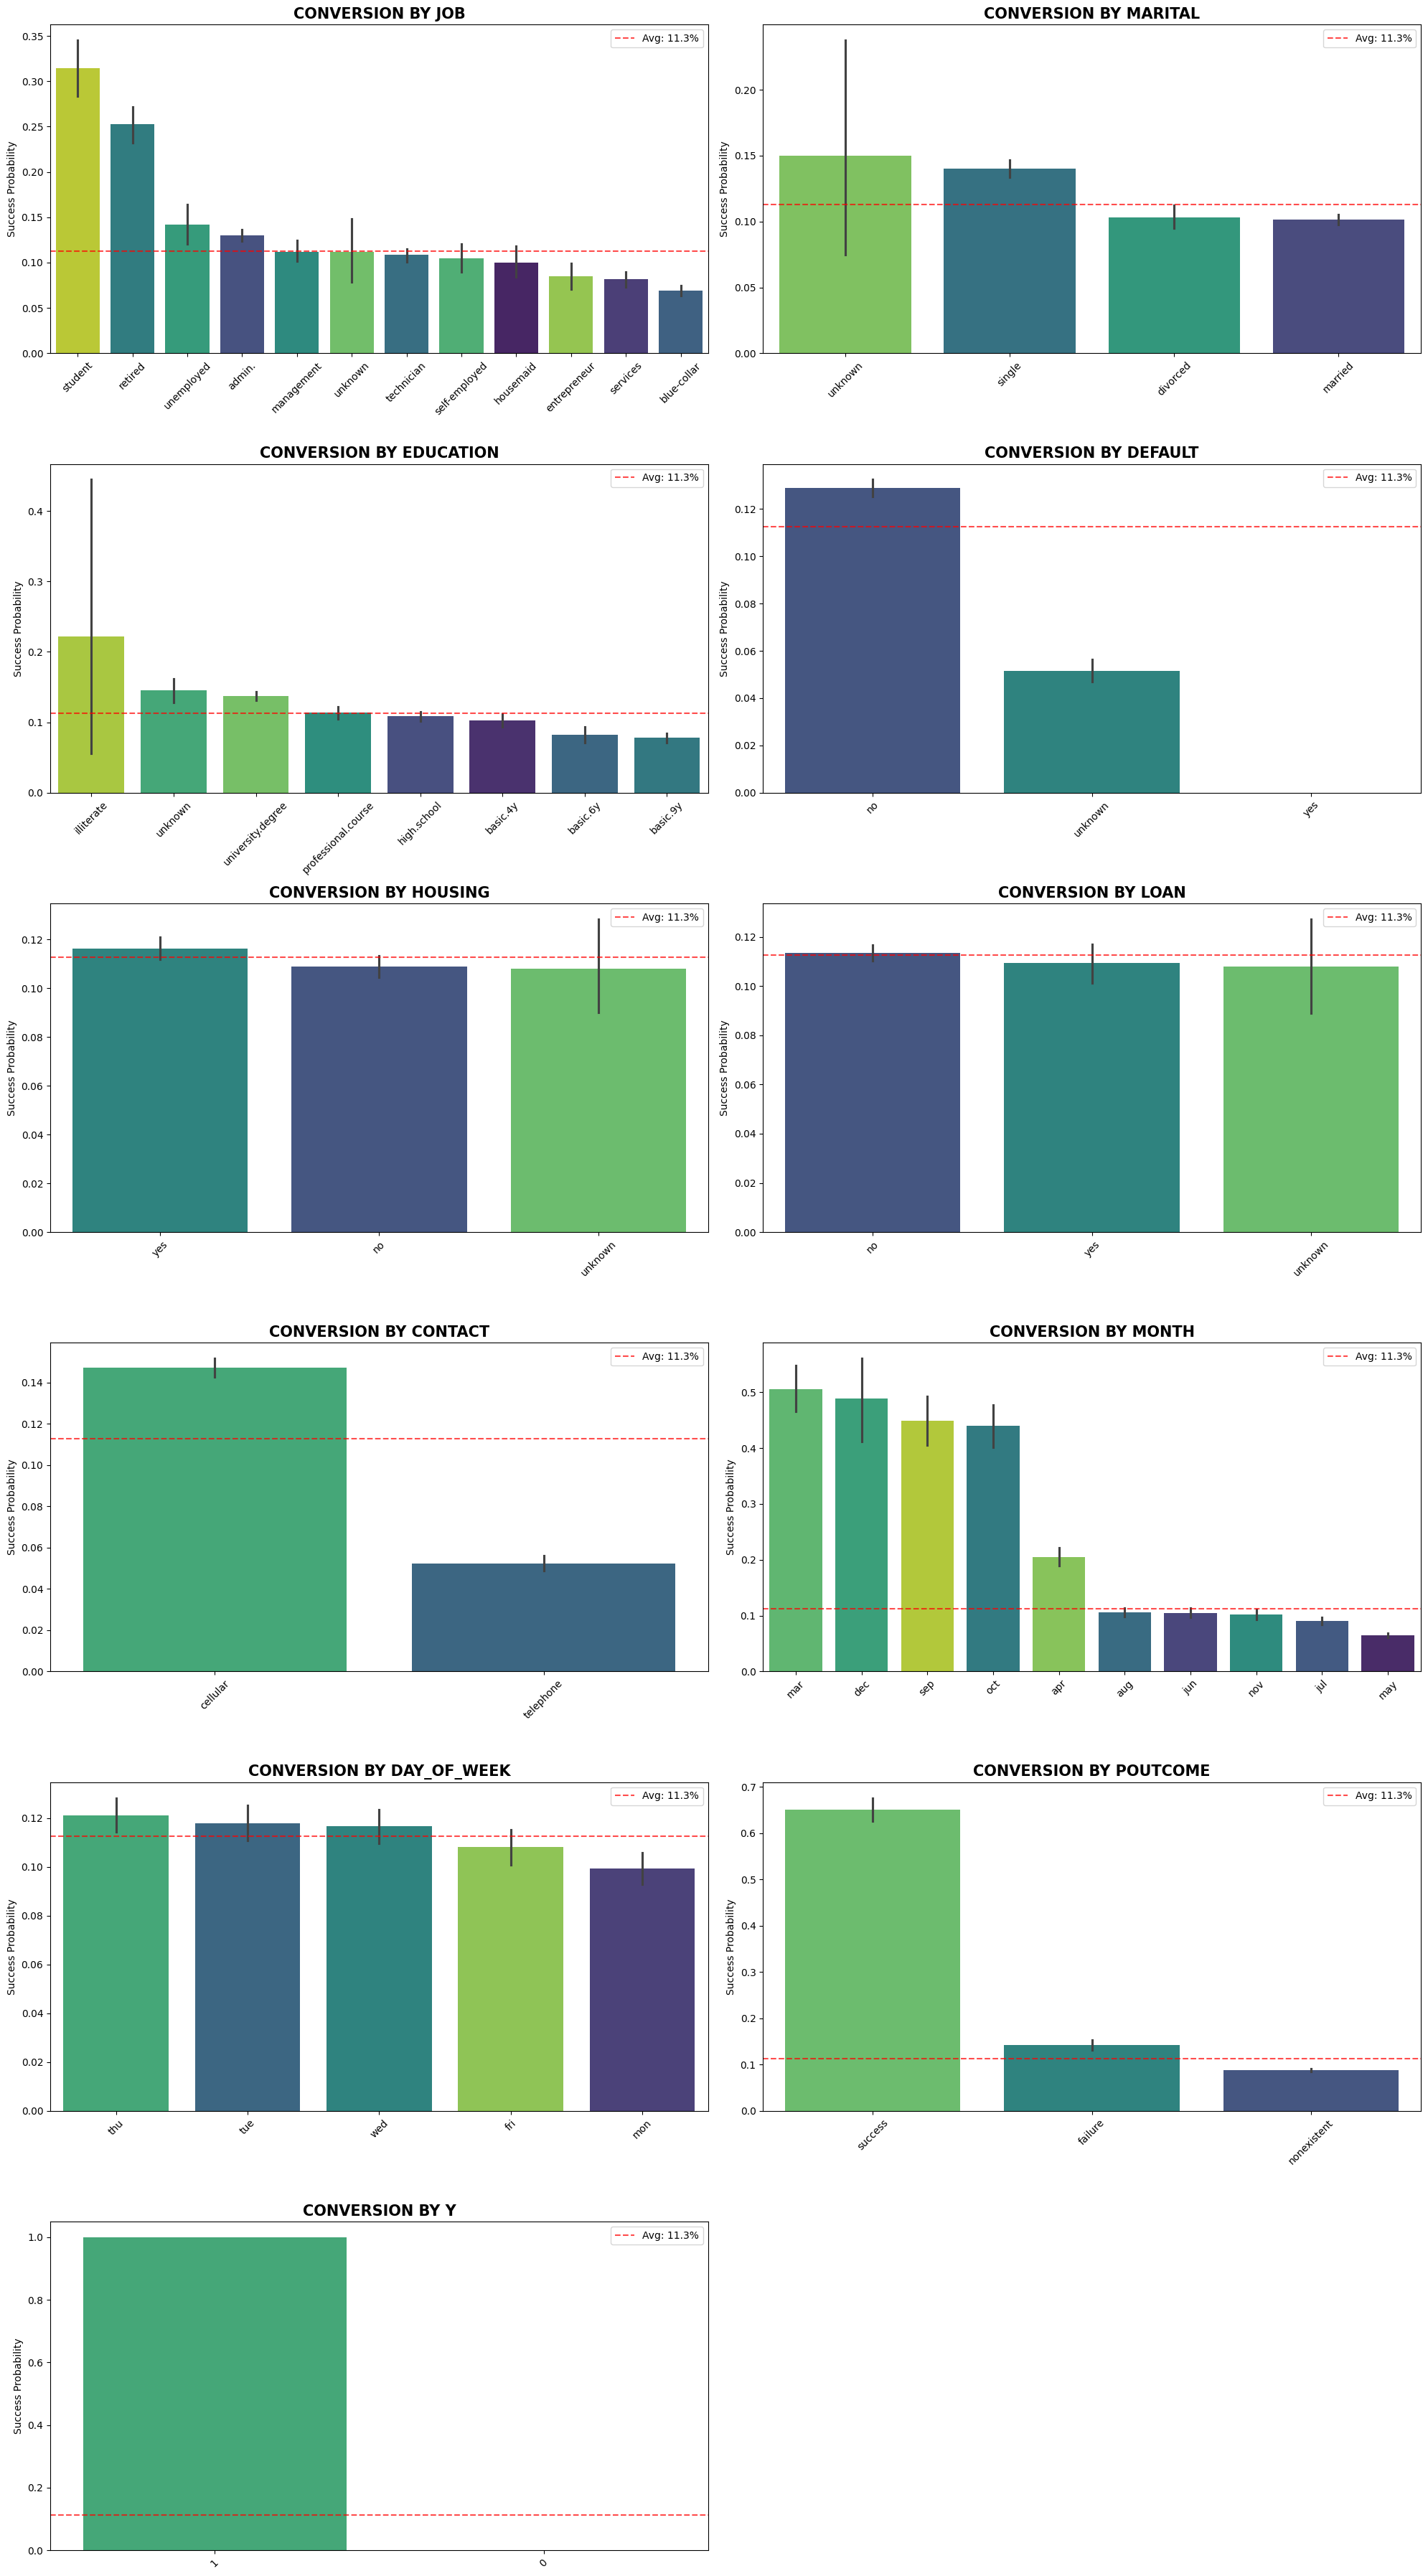

In [ ]:
out_dir = "Report\\EDA\\Convergence_Bar_Plot"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

def plot_combined_conversion_rates(df, cat_cols, target='y'):
    # 1. Pre-process target for mean calculation
    temp_df = df.copy()
    if temp_df[target].dtype == 'O':
        temp_df[target] = temp_df[target].map({'yes': 1, 'no': 0})
    
    # 2. Dynamic Grid Logic
    num_plots = len(cat_cols)
    n_cols = 2
    n_rows = (num_plots + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
    axes = axes.flatten() # Flatten to 1D for easy iteration
    
    avg_rate = temp_df[target].mean()

    # 3. Iterate and Plot
    for i, col in enumerate(cat_cols):
        # Calculate conversion order
        order = temp_df.groupby(col)[target].mean().sort_values(ascending=False).index
        
        # Plot on the specific axis
        sns.barplot(
            x=col, 
            y=target, 
            data=temp_df, 
            order=order, 
            hue=col, 
            palette='viridis', 
            ax=axes[i],
            legend=False # Legend is redundant here since X-axis labels exist
        )
        
        # Add Global Benchmark line
        axes[i].axhline(avg_rate, color='red', linestyle='--', alpha=0.7, label=f'Avg: {avg_rate:.1%}')
        
        # Formatting
        axes[i].set_title(f'CONVERSION BY {col.upper()}', fontsize=15, fontweight='bold')
        axes[i].set_ylabel('Success Probability')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(loc='upper right')

    # 4. Cleanup empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    save_path = os.path.join(out_dir, "Plot.png")
    plt.savefig(save_path, dpi=300)
    print(f"Master Signal Plot saved to: {save_path}")
    plt.show()

plot_combined_conversion_rates(df, categorical_features)


In [49]:
unique_values_2d = [df[col].unique().tolist() for col in categorical_df.columns]
print(unique_values_2d)

[['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student'], ['married', 'single', 'divorced', 'unknown'], ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate'], ['no', 'unknown', 'yes'], ['no', 'yes', 'unknown'], ['no', 'yes', 'unknown'], ['telephone', 'cellular'], ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep'], ['mon', 'tue', 'wed', 'thu', 'fri'], ['nonexistent', 'failure', 'success'], ['no', 'yes']]


In [50]:
import sys
!{sys.executable} -m pip install kaleido

In [51]:
len(categorical_features)

11

In [72]:
categorical_df['job'].value_counts().values

array([10419,  9253,  6739,  3967,  2924,  1718,  1456,  1421,  1060,
        1014,   875,   330])

In [82]:
out_dir = "Report\\EDA\\Grouped_pie_chart"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

def grouped_plot_pie(df, cat_cols):
    num_plots = len(cat_cols)
    cols = 2
    rows = (num_plots + 1) // cols
    
    fig = make_subplots(
        rows=rows, 
        cols=cols, 
        subplot_titles=[f"<b>{c.upper()} Distribution</b>" for c in cat_cols],
        specs=[[{'type': 'domain'}] * cols] * rows
    )

    for i, col in enumerate(cat_cols):
        value_counts = df[col].value_counts()
        curr_row = (i // cols) + 1
        curr_col = (i % cols) + 1
        
        fig.add_trace(
            go.Pie(
                labels=value_counts.index, 
                values=value_counts.values, 
                name=col,
                hole=0.4,
                # KEY CHANGE: Show labels and percentages on the chart itself
                textinfo='label+percent', 
                textposition='inside',
                hoverinfo="label+percent+name",
                # This ensures colors stay consistent within the subplot
                marker=dict(line=dict(color='#000000', width=1))
            ),
            row=curr_row, col=curr_col
        )

    fig.update_layout(
        height=500 * rows,
        showlegend=False, # Disable the single label bar on the right
        title_text="Market Share Analysis",
        title_x=0.5,
        font=dict(size=12)
    )
    # Save with high resolution and explicit size
    fig.write_image(
        os.path.join(out_dir, "grouped_pie_dashboard.png"),
        width=1200,   # Set a wide width for multiple columns
        height=1600,  # Increase height based on number of rows
        scale=2       # High-res multiplier (2x or 3x)
    )
    fig.show()

# Execution
grouped_plot_pie(df, categorical_features)

## Data Cleaning

In [53]:
#  for the given input we don't know the duration call already as if so we would have already know the result at the end of the everycall so no use in predictive modeling.
# If included it create data leakage i.e. when information from the future (the outcome) is included in the training data used to predict that outcome.
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})
print(df['duration'].corr(df['y_binary']))
df.drop(columns=['y_binary'], inplace= True)
df.drop(columns=['duration'], inplace= True)


0.40529726126852406


In [54]:
# Create a new column to check if the client was ever contracted before this campaign or not
df['is_previously_contracted'] = (df['pdays']!=999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)

In [55]:
df['pdays'].value_counts()

pdays
0     39676
3       439
6       412
4       118
9        64
2        61
7        60
12       58
10       52
5        46
13       36
11       28
1        26
15       24
14       20
8        18
16       11
17        8
18        7
22        3
19        3
21        2
25        1
26        1
27        1
20        1
Name: count, dtype: int64

In [56]:
df['is_previously_contracted'].value_counts()

is_previously_contracted
0    39661
1     1515
Name: count, dtype: int64

In [57]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,is_previously_contracted
35485,47,management,married,high.school,no,no,no,cellular,may,mon,...,9,2,failure,-1.8,92.893,-46.2,1.244,5099.1,no,1
33591,42,blue-collar,married,basic.4y,no,no,no,telephone,may,tue,...,0,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1,no,0
26571,42,blue-collar,single,basic.4y,unknown,yes,no,cellular,nov,thu,...,0,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no,0
21075,29,technician,single,university.degree,no,yes,no,telephone,aug,thu,...,0,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no,0
5939,31,admin.,married,high.school,unknown,no,no,telephone,may,tue,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [58]:
education_map = {
        'basic.4y': 'basic', 'basic.6y': 'basic', 'basic.9y': 'basic',
        'high.school': 'high school', 'professional.course': 'professional',
        'university.degree': 'university', 'unknown': 'unknown', 'illiterate': 'unknown'
    }

df['education'] = df['education'].map(education_map)

In [59]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,is_previously_contracted
40798,30,services,single,high school,no,yes,no,cellular,sep,thu,...,0,3,failure,-1.1,94.199,-37.5,0.878,4963.6,no,0
17839,37,services,married,high school,no,yes,no,cellular,jul,tue,...,0,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no,0
37515,36,technician,married,professional,no,yes,no,cellular,aug,thu,...,0,1,failure,-2.9,92.201,-31.4,0.873,5076.2,no,0
12595,29,services,single,high school,no,yes,no,cellular,jul,mon,...,0,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no,0
9983,29,admin.,single,university,no,yes,yes,telephone,jun,wed,...,0,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no,0


In [60]:
# Numeric columns
numeric_df = df.select_dtypes(include=['number'])


# Categorical columns
categorical_df = df.select_dtypes(include=['object'])

print(numeric_df.head())
print('\n'*3)
print(categorical_df.head())

   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1      0         0           1.1          93.994   
1   57         1      0         0           1.1          93.994   
2   37         1      0         0           1.1          93.994   
3   40         1      0         0           1.1          93.994   
4   56         1      0         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  is_previously_contracted  
0          -36.4      4.857       5191.0                         0  
1          -36.4      4.857       5191.0                         0  
2          -36.4      4.857       5191.0                         0  
3          -36.4      4.857       5191.0                         0  
4          -36.4      4.857       5191.0                         0  




         job  marital    education  default housing loan    contact month  \
0  housemaid  married        basic       no      no   no  telephone   may   
1   services  married  hi

In [61]:
numeric_df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,is_previously_contracted
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,0.221294,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.036793
std,10.42068,2.770318,1.349065,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.188256
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,0.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [62]:
df['is_previously_contracted'] = (df['pdays']!=999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)

In [63]:
df['is_previously_contracted'].unique

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
41171    1
41172    1
41173    1
41174    1
41175    1
Name: is_previously_contracted, Length: 41176, dtype: int64>

In [64]:
categorical_df.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [65]:
out_dir = "Figure\BoxPlots"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
    
for column in numeric_df.columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=numeric_df[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"boxplot_{column}.png"))
    plt.close()

In [66]:
out_dir = "Figure\BarPlots"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
for column in categorical_df.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=df[column],hue=df[column], palette= "Set2")
    plt.title(f'Countplot of {column}')
    plt.xlabel(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"boxplot_{column}.png"))
    plt.close()